In [31]:
import os, gc, sys, warnings

from glob import glob

import importlib

sys.path.append(r'/Users/xpintm/Library/CloudStorage/OneDrive-Personal/Documentos/Python/MAPJ-tools/')
import MAPJtools as mapj
#%matplotlib widget
from tqdm import tqdm
import numpy as np
import pandas as pd
import xarray as xr
from scipy.interpolate import interp1d
from scipy.optimize import fmin

import gsw
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.colors import LinearSegmentedColormap
import matplotlib as mpl
import matplotlib.pyplot as plt
import cmocean.cm as cmo
sys.path.append(r'/Users/xpintm/Library/CloudStorage/OneDrive-Personal/Documentos/Python/gliderad2cpV2/')

from gliderad2cp import process_currents, process_shear, process_bias, tools

warnings.filterwarnings(action='ignore', message='Mean of empty slice')
warnings.filterwarnings(action='ignore', message='invalid value encountered in divide')
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import shapefile
from cartopy.io.shapereader import Reader
import cartopy.feature as cfeature
from matplotlib.gridspec import GridSpec


In [32]:
def nearest_indices(time_array, target_times):
    idx = np.searchsorted(time_array, target_times)
    idx = np.clip(idx, 1, len(time_array)-1)
    left = time_array[idx-1]
    right = time_array[idx]
    # Choose closer one
    idx -= (target_times - left) < (right - target_times)
    return idx
def extract_nearest_timeseries(ds,d57):
    """
    Extract a time series of nearest grid point data from an xarray.Dataset.
    
    Parameters:
        ds (xarray.Dataset): The input dataset with 'time', 'latitude', 'longitude' coordinates.
        lonD (array-like): Array of longitudes corresponding to each time step.
        latD (array-like): Array of latitudes corresponding to each time step.
        
    Returns:
        xarray.Dataset: A new dataset with dimension 'time' containing data variables
                        at the nearest (longitude, latitude) point for each time.
    """
    # List to store the subset for each time step
    data_list = []
    idx__ = nearest_indices(ds.time.values,d57.time_profile.values)
    idx__ = np.unique(idx__)
    #ds.isel(time=idx__).time.values
    idx_ = nearest_indices(d57.time_profile.values, ds.time)
    idx_=np.unique(idx_)
    d57.time_profile[idx_]
    latD=d57.latitude[:,idx_].mean(axis=0).values
    lonD=d57.longitude[:,idx_].mean(axis=0).values
    # # Ensure the number of positions matches the time dimension length
    # if len(lonD) != ds.dims['time'] or len(latD) != ds.dims['time']:
    #     raise ValueError("Length of lonD and latD must equal the length of the 'time' dimension in the dataset.")

    # Loop over each time step
    for i, time_value in enumerate(d57.time_profile[idx_].values):
        #print(time_value)
        # Select the data at the nearest (lon, lat) for this time step
        subset = ds.sel(
            time=time_value,
            longitude=lonD[i],
            latitude=latD[i],
            method='nearest'
        )
        data_list.append(subset)

    # Concatenate along the time dimension
    ds_subset = xr.concat(data_list, dim="time")
    
    # Optionally, reassign the original time coordinate (if needed)
    ds_subset = ds_subset.assign_coords(time=d57.time_profile[idx_].values)
    return ds_subset

def plot_map(ax,times,tidx):
    """
    Plot land, coastline, bathymetry, and reference lines on the given axes.

    Parameters
    ----------
    ax : matplotlib Axes
        Axes object where the map will be plotted.
    """
    # times to plot
    #times = np.array(['2024-11-10','2024-11-25','2024-12-07','2024-12-25','2025-01-15','2025-02-03'], dtype='datetime64[ns]')
    idx_57 = nearest_indices(d57.time_profile.values, times)#.resample(time_profile='1D').mean().values
    idx_70 = nearest_indices(d70.time_profile.values, times)#.resample(time_profile='1D').mean().values
    idx_GLO = nearest_indices(GLO.time.values, times)
    gebco= xr.open_dataset('/Volumes/WD_BLACK/2024_OMAN/Bathymetry/gebco_2023_n30.0_s-5.0_w30.0_e80.0.nc')
    bath_levels = [-2000, -1000, -100]
    # Load GEBCO
    elevation = gebco.elevation
    lon = gebco.lon
    lat = gebco.lat
    # Subset
    lon_min, lon_max = 56.25, 59.25
    lat_min, lat_max = 23, 26
    elev_sub = elevation.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))
    lon2d, lat2d = np.meshgrid(elev_sub.lon, elev_sub.lat)
    # Glo lims
    col_min=np.percentile(GLO.adt.min().values, 5)
    col_max=np.percentile(GLO.adt.max().values, 95)
    #tidx=5
    #fig,ax = plt.subplots(figsize=(4.5, 4.5), dpi=200)
    #ax.set_extent([lon_min, lon_max, lat_min, lat_max])
    # Grid
    #gl = ax.grid(linewidth=0.3, color='gray',linestyle='--', alpha=1,zorder=5)
    # Land
    ax.contourf(lon2d, lat2d, elev_sub > 0, levels=[0.5, 1.5], colors='lightgray', zorder=5,alpha=1)
    # Coastline
    ax.contour(lon2d, lat2d, elev_sub, levels=[0], colors='k', linewidths=0.7, zorder=6)
    # Bathymetry
    elev_masked = np.ma.masked_invalid(elev_sub.values)
    bath = ax.contour(lon2d, lat2d, elev_masked, levels=bath_levels,colors='w', linestyles='--', linewidths=0.7, zorder=3)
    ax.plot([coords["M0"][1], coords["M2"][1]], [coords["M0"][0], coords["M2"][0]],color='k', linestyle='-', linewidth=2, zorder=8)  # Vertical line (M0 ↔ M2)
    ax.plot([coords["NW"][1], coords["SE"][1]], [coords["NW"][0], coords["SE"][0]],color='k', linestyle='-', linewidth=2, zorder=8)  # Horizontal line (NW ↔ SE)
    ps=ax.contourf(GLO.longitude, GLO.latitude, GLO.vorticity_local[idx_GLO[tidx],:,:],levels=500, cmap='bwr',zorder=1,vmin=-3,vmax=3)
    ax.contour(GLO.longitude, GLO.latitude, GLO.vorticity_local[idx_GLO[tidx],:,:],linestyles='-.', colors='k', linewidths=1,alpha=1, levels=np.array([0]),zorder=8)# 0 vorticity
    ax.contour(GLO.longitude, GLO.latitude, GLO.adt[idx_GLO[tidx],:,:],levels=np.linspace(col_min, col_max, 50),colors='k',linewidths=0.3,zorder=4)
    ax.quiver(GLO.longitude, GLO.latitude,GLO.ugos[idx_GLO[tidx],:,:], GLO.vgos[idx_GLO[tidx],:,:],scale=2, color='k',alpha=0.7,scale_units='inches', angles='uv',zorder=4)
    ax.set_ylim(lat_min, lat_max)
    ax.set_xlim(lon_min, lon_max)
    ax.plot(d57.longitude[:,idx_57[tidx]].mean().values, d57.latitude[:,idx_57[tidx]].mean().values,marker='.', color='m', markersize=4,zorder=9)
    ax.plot(d70.longitude[:,idx_70[tidx]].mean().values, d70.latitude[:,idx_70[tidx]].mean().values,marker='d', color='m', markersize=4,zorder=9)
    ax.text(56.5,23.25,times[tidx].astype('datetime64[D]').astype(str), fontsize=20,zorder=7);

def compute_vorticity(ds):
    # Earth's radius in meters
    R = 6371000  # meters
    # Compute grid spacing in meters
    dlat = (ds.latitude.values[1] - ds.latitude.values[0]) * (R * np.pi / 180)  # dy
    dlon = (ds.longitude.values[1] - ds.longitude.values[0]) * (R * np.pi / 180) * np.cos(np.deg2rad(ds.latitude.values[:, np.newaxis]))  # dx
    
    # Reshape dlat and dlon to align with the dataset dimensions
    dlat_3d = np.broadcast_to(dlat, (ds.time.size, ds.latitude.size, ds.longitude.size))  # (time, lat, lon)
    dlon_3d = np.broadcast_to(dlon, (ds.time.size, ds.latitude.size, ds.longitude.size))  # (time, lat, lon)

    # Compute gradients using xarray's differentiate method
    dv_dx = ds.vgos.differentiate("longitude") / dlon_3d
    du_dy = ds.ugos.differentiate("latitude") / dlat_3d
    
    # Compute vorticity
    vorticity = dv_dx - du_dy
    
    # Assign to dataset using .data to extract raw values
    ds['vorticity'] = (('time', 'latitude', 'longitude'), vorticity.data)
    # Compute Coriolis parameter f = 2 * Omega * sin(latitude)
    Omega = 7.2921e-5  # Earth's rotation rate in rad/s
    f = 2 * Omega * np.sin(np.deg2rad(ds.latitude.values[:, np.newaxis]))
    
    # Reshape f to match dataset dimensions
    f_3d = np.broadcast_to(f, (ds.time.size, ds.latitude.size, ds.longitude.size))
    
    # Assign Coriolis parameter to dataset
    ds['f'] = (('time', 'latitude', 'longitude'), f_3d)
    ds['vorticity_local'] = (('time', 'latitude', 'longitude'), vorticity.data/f_3d)
    return ds

def viscosity(s, t, rho):
    """
    Compute molecular and kinematic viscosity of seawater.

    Parameters:
    -----------
    s : Salinity [g/kg]
    t : Temperature [°C] (in-situ)
    rho : Density [kg/m^3]

    Returns:
    --------
    nu : Kinematic viscosity [m²/s]
    mu : Dynamic (molecular) viscosity [Pa·s]
    """
    # Coefficients from Millero (1974) / Peters & Siedler
    a0 = 2.5116e-6
    a1 = 1.2199e-6
    b0 = 1.4342e-6
    b1 = 1.8267e-8
    c0 = 1.002e-3
    d0 = 1.1709
    d1 = 1.827e-3
    d2 = 89.93

    # Molecular viscosity at salinity = 0
    mu0 = c0 * 10 ** ((d0 * (20 - t) - d1 * (t - 20) ** 2) / (t + d2))

    # Dynamic viscosity at salinity = s
    rs = rho * s
    mu = mu0 * (1 + (a0 + a1 * t) * np.sqrt(rs) + (b0 + b1 * t) * rs)

    # Kinematic viscosity
    nu = mu / rho

    return nu, mu
def load_fast(uid_, uid_code, varname):
    """
    Load the fast parquet file corresponding to uid_code
    and return P_fast plus the requested variable(s).

    Parameters
    ----------
    uid_ : xarray.Dataset
        The uid_files.nc opened with xr.open_dataset
    uid_code : int
        Numeric identifier of the file
    varname : str or list of str
        Variable(s) to load in addition to P_fast

    Returns
    -------
    ds : xarray.Dataset
        Contains P_fast and requested variable(s)
    """
    if isinstance(varname, str):
        varname = [varname]

    # Find row for this uid_code
    matches = (uid_['uid_code'].values == uid_code).nonzero()[0]
    if len(matches) == 0:
        raise ValueError(f"uid_code {uid_code} not found in uid_files.nc")
    row = int(matches[0])

    source_dir  = str(uid_['source_dir'].values[row])
    source_file = str(uid_['source_file'].values[row])

    # Build fast filename
    fast_file = source_file.replace('.pqt', '_fast.pqt')
    fast_path = os.path.join('/Volumes/WD_BLACK/2024_OMAN', source_dir, fast_file)

    if not os.path.exists(fast_path):
        raise FileNotFoundError(f"Fast file not found: {fast_path}")

    # Always include P_fast
    cols = ['P_fast'] + varname
    df = pd.read_parquet(fast_path, columns=cols)

    # Convert to xarray Dataset
    ds = xr.Dataset.from_dataframe(df)

    # Add uid_code as a coordinate
    ds = ds.assign_coords(uid_code=uid_code)

    return ds


In [33]:
# # Default settings for all figures
# plt.rcParams.update({
#     "figure.figsize": (4.5, 4.5),         # inches — suitable for 1-column in Word
#     "figure.dpi": 100,                    # high resolution for export
#     "font.size": 12,                      # base font size
#     "axes.titlesize": 11,                 # title font
#     "axes.labelsize": 10,                 # axis labels
#     "xtick.labelsize": 10,
#     "ytick.labelsize": 10,
#     "legend.fontsize": 10,
#     "axes.linewidth": 0.8,
#     "lines.linewidth": 1,
#     "xtick.direction": "out",
#     "ytick.direction": "out",
#     "xtick.major.size": 3,
#     "ytick.major.size": 3,
#     "savefig.dpi": 600,                   # savefig resolution
#     "savefig.bbox": "tight",
#     "font.family": "sans-serif",
#     "font.sans-serif": ["Arial"]         # Word-compatible font
# })

# Colormaps

In [34]:
cmap_name = 'flags'
colors=[(1,1,1),(0,0.447,0.741),(0.850,0.325,0.098),(0.929,0.694,0.125),(0.635,0.078,0.184),(0.466,0.674,0.188)]
cmap_flag = LinearSegmentedColormap.from_list(cmap_name, colors, N=6)
cmap_epsi=plt.get_cmap('cmo.thermal',6)
# Define discrete color map for Turner angle interpretation
cmap_name = 'Tu_regimes'
colors = [
    (0.0, 0.0, 0.5),     # Strong convective diffusion (dark blue)
    (0.4, 0.7, 1.0),     # Weak convective diffusion (light blue)
    (1.0, 1.0, 1.0),     # Double stable (white)
    (1.0, 0.6, 0.0),     # Weak salt fingering (orange)
    (0.8, 0.0, 0.0)      # Strong salt fingering (red)
]
# Construct colormap with 5 bins matching the regimes
cmap_Tu = LinearSegmentedColormap.from_list(cmap_name, colors, N=5)

# Load Glider data

In [35]:
#uid_ = xr.open_dataset('/Volumes/WD_BLACK/2024_OMAN/uid_files.nc')

In [36]:
d57=xr.open_dataset('/Volumes/WD_BLACK/2024_OMAN/Data4Zenodo/SEA057_gridded_pprofile_processed.nc')
# Define coordinates
coords = {
    "M2": (24.29972, 57.67194),
    "NW": (24.26333, 57.51667),
    "SE": (24.16500, 57.70000),
    "M0": (24.13500, 57.55444),
    "VM": (24.21194, 57.61222)
}
a=500

# Load SSH

In [37]:
GLO=xr.open_dataset('/Volumes/WD_BLACK/2024_OMAN/Data_download/GLO/AVISO/cmems_obs-sl_glo_phy-ssh_nrt_allsat-l4-duacs-0.125deg_P1D_1755079926474.nc')
GLO

<xarray.Dataset> Size: 14MB
Dimensions:    (time: 182, latitude: 40, longitude: 48)
Coordinates:
  * time       (time) datetime64[ns] 1kB 2024-10-01 2024-10-02 ... 2025-03-31
  * latitude   (latitude) float32 160B 22.06 22.19 22.31 ... 26.69 26.81 26.94
  * longitude  (longitude) float32 192B 55.06 55.19 55.31 ... 60.69 60.81 60.94
Data variables:
    adt        (time, latitude, longitude) float32 1MB ...
    err_sla    (time, latitude, longitude) float32 1MB ...
    err_ugosa  (time, latitude, longitude) float32 1MB ...
    err_vgosa  (time, latitude, longitude) float32 1MB ...
    flag_ice   (time, latitude, longitude) float32 1MB ...
    sla        (time, latitude, longitude) float32 1MB ...
    ugos       (time, latitude, longitude) float32 1MB ...
    ugosa      (time, latitude, longitude) float32 1MB ...
    vgos       (time, latitude, longitude) float32 1MB ...
    vgosa      (time, latitude, longitude) float32 1MB ...
Attributes:
    Conventions:       CF-1.11
    title:             NRT merged all satellites Global Ocean Gridded SSALTO/...
    institution:       CLS, CNES
    source:            Altimetry measurements
    history:           2025-04-17 20:03:53Z: Creation
    contact:           servicedesk.cmems@mercator-ocean.eu
    references:        http://marine.copernicus.eu
    comment:           Sea Surface Height measured by Altimetry and derived v...
    subset:source:     ARCO data downloaded from the Marine Data Store using ...
    subset:productId:  SEALEVEL_GLO_PHY_L4_NRT_008_046
    subset:datasetId:  cmems_obs-sl_glo_phy-ssh_nrt_allsat-l4-duacs-0.125deg_...
    subset:date:       2025-08-13T10:12:06.474Z

# Map


In [38]:
def nearest_indices(time_array, target_times):
    idx = np.searchsorted(time_array, target_times)
    idx = np.clip(idx, 1, len(time_array)-1)
    left = time_array[idx-1]
    right = time_array[idx]
    # Choose closer one
    idx -= (target_times - left) < (right - target_times)
    return idx
def plot_map(ax,times,tidx):
    """
    Plot land, coastline, bathymetry, and reference lines on the given axes.

    Parameters
    ----------
    ax : matplotlib Axes
        Axes object where the map will be plotted.
    """
    # times to plot
    #times = np.array(['2024-11-10','2024-11-25','2024-12-07','2024-12-25','2025-01-15','2025-02-03'], dtype='datetime64[ns]')
    idx_57 = nearest_indices(d57.time_profile.values, times)
    idx_GLO = nearest_indices(GLO.time.values, times)
    gebco= xr.open_dataset('/Volumes/WD_BLACK/2024_OMAN/Bathymetry/gebco_2023_n30.0_s-5.0_w30.0_e80.0.nc')
    bath_levels = [-2000, -1000, -100]
    # Load GEBCO
    elevation = gebco.elevation
    lon = gebco.lon
    lat = gebco.lat
    # Subset
    lon_min, lon_max = 56.25, 59.25
    lat_min, lat_max = 23, 26
    elev_sub = elevation.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))
    lon2d, lat2d = np.meshgrid(elev_sub.lon, elev_sub.lat)
    # Glo lims
    col_min=np.percentile(GLO.adt.min().values, 5)
    col_max=np.percentile(GLO.adt.max().values, 95)
    #tidx=5
    #fig,ax = plt.subplots(figsize=(4.5, 4.5), dpi=200)
    #ax.set_extent([lon_min, lon_max, lat_min, lat_max])
    # Grid
    #gl = ax.grid(linewidth=0.3, color='gray',linestyle='--', alpha=1,zorder=5)
    # Land
    ax.contourf(lon2d, lat2d, elev_sub > 0, levels=[0.5, 1.5], colors='lightgray', zorder=2,alpha=1)
    # Coastline
    ax.contour(lon2d, lat2d, elev_sub, levels=[0], colors='k', linewidths=0.1, zorder=2)
    # Bathymetry
    elev_masked = np.ma.masked_invalid(elev_sub.values)
    bath = ax.contour(lon2d, lat2d, elev_masked, levels=bath_levels,colors='w', linestyles='--', linewidths=0.4, zorder=3)
    ax.plot([coords["M0"][1], coords["M2"][1]], [coords["M0"][0], coords["M2"][0]],color='k', linestyle='-', linewidth=1, zorder=3)  # Vertical line (M0 ↔ M2)
    ax.plot([coords["NW"][1], coords["SE"][1]], [coords["NW"][0], coords["SE"][0]],color='k', linestyle='-', linewidth=1, zorder=3)  # Horizontal line (NW ↔ SE)
    ps=ax.contourf(GLO.longitude, GLO.latitude, GLO.vorticity_local[idx_GLO[tidx],:,:],levels=500,cmap=cmo.balance,zorder=1,vmin=-3,vmax=3)
    ax.contour(GLO.longitude, GLO.latitude, GLO.adt[idx_GLO[tidx],:,:],levels=np.linspace(col_min, col_max, 50),colors='k',linewidths=0.1,zorder=1)
    ax.quiver(GLO.longitude, GLO.latitude,GLO.ugos[idx_GLO[tidx],:,:], GLO.vgos[idx_GLO[tidx],:,:],scale=7, color='k',alpha=0.7)
    ax.set_ylim(lat_min, lat_max)
    ax.set_xlim(lon_min, lon_max)
    ax.plot(d57.longitude[:,idx_57[tidx]].mean().values, d57.latitude[:,idx_57[tidx]].mean().values,'x', color='m', markersize=3,zorder=5)
    ax.text(56.5,23.25,times[tidx].astype('datetime64[D]').astype(str), fontsize=9);


(500.0, 0.0)

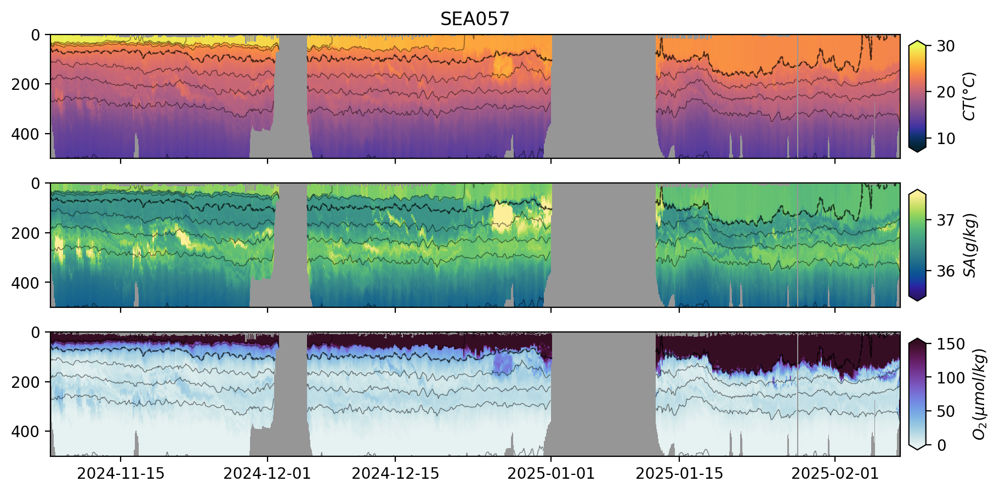

In [39]:
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(10, 5),sharex=True,dpi=200)
ax[0].set_facecolor(np.array([1, 1, 1]) / 1.7)
mesh=ax[0].pcolormesh(d57.time_profile, d57.depth, d57.cons_temperature, shading='auto', cmap='cmo.thermal',vmin=8, vmax=30)
cax = ax[0].inset_axes([1.01, 0.05, 0.02, 0.9])
cbar = fig.colorbar(mesh, cax=cax, label=r'$CT (°C)$', extend='both', pad=0.02)
ax[0].contour(d57.time_profile, d57.depth, d57.potential_density, colors='k', linewidths=0.5,alpha=0.5, levels=np.arange(1000, 1030, 0.5))
ax[0].contour(d57.time_profile, d57.depth, d57.potential_density,linestyles='--', colors='k', linewidths=1,alpha=0.5, levels=np.array([1025]))
ax[0].set_ylim(a,0)
ax[0].set_title('SEA057')
ax[1].set_facecolor(np.array([1, 1, 1]) / 1.7)
mesh=ax[1].pcolormesh(d57.time_profile, d57.depth, d57.abs_salinity, shading='auto', cmap='cmo.haline',vmin=35.5, vmax=37.5)
cax = ax[1].inset_axes([1.01, 0.05, 0.02, 0.9])
cbar = fig.colorbar(mesh, cax=cax, label=r'$SA (g/kg)$', extend='both', pad=0.02)
ax[1].contour(d57.time_profile, d57.depth, d57.potential_density, colors='k', linewidths=0.5,alpha=0.5, levels=np.arange(1000, 1030, 0.5))
ax[1].contour(d57.time_profile, d57.depth, d57.potential_density,linestyles='--', colors='k', linewidths=1,alpha=0.5, levels=np.array([1025]))
ax[1].set_ylim(a,0)
ax[2].set_facecolor(np.array([1, 1, 1]) / 1.7)
mesh=ax[2].pcolormesh(d57.time_profile, d57.depth, d57.oxygen_corrected, shading='auto', cmap='cmo.dense',vmin=0, vmax=150)
cax = ax[2].inset_axes([1.01, 0.05, 0.02, 0.9])
cbar = fig.colorbar(mesh, cax=cax, label=r'$O_2 (µmol/kg)$', extend='both', pad=0.02)
ax[2].contour(d57.time_profile, d57.depth, d57.potential_density, colors='k', linewidths=0.5,alpha=0.5, levels=np.arange(1000, 1030, 0.5))
ax[2].contour(d57.time_profile, d57.depth, d57.potential_density,linestyles='--', colors='k', linewidths=1,alpha=0.5, levels=np.array([1025]))
ax[2].set_ylim(a,0)


In [40]:
d57 = mapj.compute_N2(d57)
d57 = mapj.compute_Tu(d57)
d57["spiciness"] = (["depth", "time_profile"], mapj.spiciness_(d57))
d57 = mapj.compute_Ri(d57)


In [41]:
print(d57.time_profile[0])
print(d57.time_profile[-1])



<xarray.DataArray 'time_profile' ()> Size: 8B
array('2024-11-07T08:18:17.000000000', dtype='datetime64[ns]')
Coordinates:
    profile_index  float64 8B ...
    time_profile   datetime64[ns] 8B 2024-11-07T08:18:17
Attributes:
    long_name:      Profile time
    standard_name:  time
    comment:        Representative time associated with each glider profile
    accuracy:       
    precision:      
    platform:       SeaExplorer glider
    resolution:     
<xarray.DataArray 'time_profile' ()> Size: 8B
array('2025-02-08T02:32:34.000000000', dtype='datetime64[ns]')
Coordinates:
    profile_index  float64 8B ...
    time_profile   datetime64[ns] 8B 2025-02-08T02:32:34
Attributes:
    long_name:      Profile time
    standard_name:  time
    comment:        Representative time associated with each glider profile
    accuracy:       
    precision:      
    platform:       SeaExplorer glider
    resolution:     


/opt/anaconda3/envs/myenv/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:821: RuntimeWarning: invalid value encountered in log10
  result_data = func(*input_data)


(500.0, 0.0)

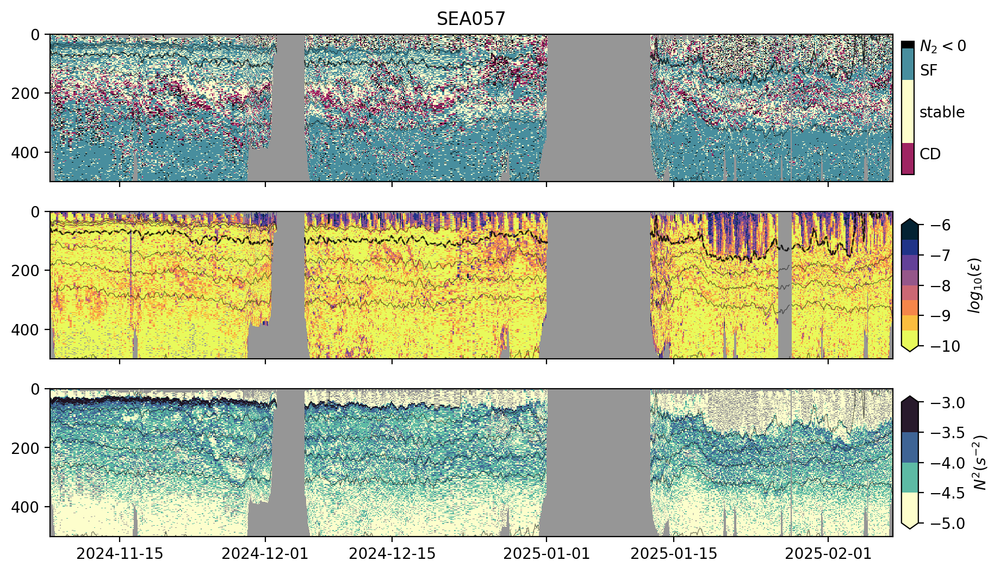

In [42]:
fig,axs=plt.subplots(nrows=3, ncols=1, figsize=(10, 6),sharex=True,dpi=200)
axs[0].set_facecolor(np.array([1, 1, 1]) / 1.7)
mapj.plot_turner_angle(d57.Tu,ax=axs[0],colc=2)
axs[0].contour(d57.time_profile, d57.depth, d57.potential_density, colors='k', linewidths=0.5,alpha=0.5, levels=np.arange(1000, 1030, 0.5))
axs[0].contour(d57.time_profile, d57.depth, d57.potential_density,linestyles='--', colors='k', linewidths=1,alpha=0.5, levels=np.array([1025]))

axs[0].set_ylim(a,0)
axs[0].set_title('SEA057')
axs[1].set_facecolor(np.array([1, 1, 1]) / 1.7)
mesh=axs[1].pcolormesh(d57.time_profile,d57.depth,np.log10(d57.epsi_QC_gm),vmin=-10,vmax=-6,cmap = cmo.thermal_r.resampled(8),zorder=1)#plt.colormaps['Spectral_r'].resampled(6)
cax = axs[1].inset_axes([1.01, 0.05, 0.02, 0.9])
cbar = fig.colorbar(mesh, cax=cax, label=r'$log_{10}(\epsilon)$', extend='both', pad=0.02)
axs[1].contour(d57.time_profile, d57.depth, d57.potential_density, colors='k', linewidths=0.5,alpha=0.5, levels=np.arange(1000, 1030, 0.5))
axs[1].contour(d57.time_profile, d57.depth, d57.potential_density,linestyles='--', colors='k', linewidths=1,alpha=0.5, levels=np.array([1025]))

axs[1].set_ylim(a,0)

axs[2].set_facecolor(np.array([1, 1, 1]) / 1.7)
mesh=axs[2].pcolormesh(d57.time_profile, d57.depth, np.log10(d57.N2), shading='auto', cmap=cmo.deep.resampled(4),vmin=-5, vmax=-3)
cax = axs[2].inset_axes([1.01, 0.05, 0.02, 0.9])
cbar = fig.colorbar(mesh, cax=cax, label=r'$N^2 (s^{-2})$', extend='both', pad=0.02)
axs[2].contour(d57.time_profile, d57.depth, d57.potential_density, colors='k', linewidths=0.5,alpha=0.5, levels=np.arange(1000, 1030, 0.5))
axs[1].contour(d57.time_profile, d57.depth, d57.potential_density,linestyles='--', colors='k', linewidths=1,alpha=0.5, levels=np.array([1025]))

axs[2].set_ylim(a,0)


(-110.0, 110.0)

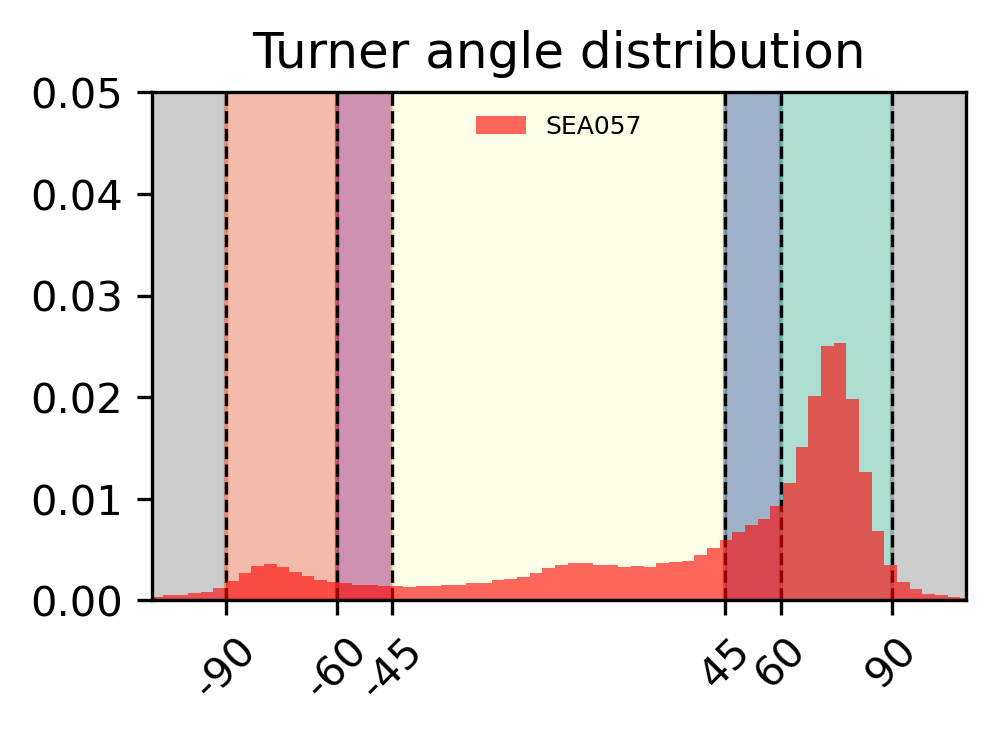

In [43]:
import matplotlib.patches as patches
# Define Tu thresholds and regime colors
Tu_bounds = [-120, -90, -60, -45, 45, 60, 90, 120]  # Extended limits for patching
colors = [
    cmo.gray.resampled(4)(2)[:3],     # Invalid
    cmo.matter.resampled(4)(1)[:3],  # Strong CD
    cmo.matter.resampled(4)(2)[:3],  # Weak CD
    cmo.deep.resampled(4)(0)[:3],    # Stable
    cmo.deep.resampled(4)(2)[:3],    # Weak SF
    cmo.deep.resampled(4)(1)[:3],    # Strong SF
    cmo.gray.resampled(4)(2)[:3]     # Invalid
]
labels = ['Strong CD', 'Weak CD', 'Stable', 'Weak SF', 'Strong SF', 'Invalid']
# Plot setup
fig, ax = plt.subplots(figsize=(3.5, 2.2), dpi=300)

# Plot background patches first
for i in range(len(colors)):
    ax.add_patch(
        patches.Rectangle(
            (Tu_bounds[i], 0),
            Tu_bounds[i+1] - Tu_bounds[i],
            1.1,  # Adjust based on expected max density
            color=colors[i],
            alpha=0.5,
            zorder=0
        )
    )

# Add vertical lines
for x in [-90, -60, -45, 45, 60, 90]:
    ax.axvline(x, color='k', linestyle='--', linewidth=0.8, zorder=1)
# Mask Tu where potential_density <= 1025
tu57_masked = d57.Tu.where((d57.potential_density >= 1025)&(d57.pressure < 500)).values.flatten()

# Remove NaNs
tu57_masked = tu57_masked[~np.isnan(tu57_masked)]
# Plot histograms
_=ax.hist(tu57_masked, bins=100, density=True, color='r', alpha=0.6, label='SEA057', zorder=2)
ax.legend(loc='upper center', fontsize=6, frameon=False)
plt.title('Turner angle distribution')
ax.set_ylim(0, 0.05)  # Adjust based on your data
ax.set_xticks([-120, -90, -60, -45, 45, 60, 90, 120])
ax.set_xticklabels(['-120', '-90', '-60', '-45', '45', '60', '90', '120'], rotation=45)
plt.xlim(-110, 110)  # Reverse x-axis for better readability


In [44]:
d57_inrho=mapj.grid_in_rho(d57)
delta_rho=d57_inrho.density[1].values-d57_inrho.density[0].values
spiciness_curv=np.gradient(np.gradient((d57_inrho.spiciness.values),delta_rho,axis=0),delta_rho, axis=0)
d57_inrho = d57_inrho.assign({"spiciness_curvature" : (("density","time_profile"),spiciness_curv)})


Interpolating variables: 100%|██████████| 21/21 [00:06<00:00,  3.16it/s]


In [45]:
d57_inp=mapj.grid_in_P(d57_inrho, d57)
d57["spiciness_curvature"] =d57_inp.spiciness_curvature



Regridding to pressure grid: 100%|██████████| 20/20 [00:03<00:00,  5.69it/s]


In [46]:
anom_d57_inrho = (d57_inrho-d57_inrho.mean(dim="time_profile", skipna=True))
anom_d57_inp=mapj.grid_in_P(anom_d57_inrho, d57)


Regridding to pressure grid: 100%|██████████| 20/20 [00:03<00:00,  5.70it/s]


(500.0, 0.0)

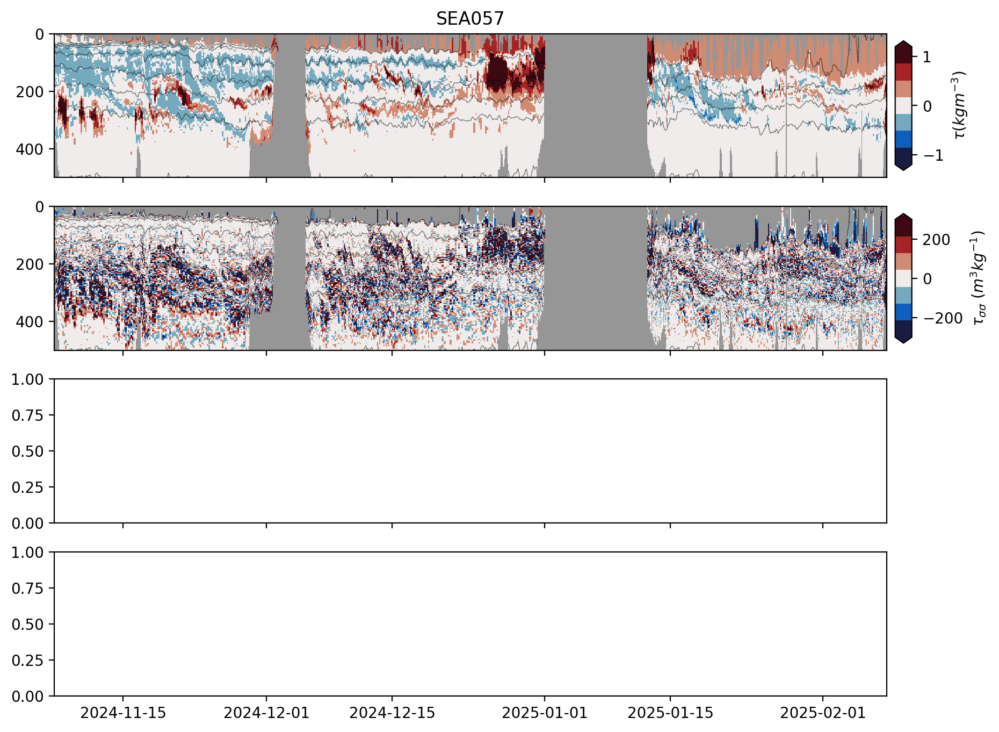

In [47]:
fig,axs=plt.subplots(nrows=4, ncols=1, figsize=(10,8),sharex=True,dpi=200)
axs[0].set_facecolor(np.array([1, 1, 1]) / 1.7)
mesh=axs[0].pcolormesh(d57.time_profile, d57.depth, anom_d57_inp.spiciness, shading='auto', cmap=cmo.balance.resampled(7),vmin=-1.2, vmax=1.2)
cax = axs[0].inset_axes([1.01, 0.05, 0.02, 0.9])
axs[0].contour(d57.time_profile, d57.depth, d57.potential_density, colors='k', linewidths=0.5,alpha=0.5, levels=np.arange(1000, 1030, 0.5))
axs[0].set_ylim(a,0)
cbar = fig.colorbar(mesh, cax=cax,label=r'$\tau (kg m^{-3})$', extend='both', pad=0.02)
axs[0].set_ylim(a,0)
axs[0].set_title('SEA057')

axs[1].set_facecolor(np.array([1, 1, 1]) / 1.7)
mesh=axs[1].pcolormesh(d57.time_profile, d57.depth, d57.spiciness_curvature, shading='auto',  cmap=cmo.balance.resampled(7),vmin=-300, vmax=300)
cax = axs[1].inset_axes([1.01, 0.05, 0.02, 0.9])
axs[1].contour(d57.time_profile, d57.depth, d57.potential_density, colors='k', linewidths=0.5,alpha=0.5, levels=np.arange(1000, 1030, 0.5))
axs[1].set_ylim(a,0)
cbar = fig.colorbar(mesh, cax=cax,label=r'$\tau_{\sigma \sigma}\ (m^3kg^{-1})$', extend='both', pad=0.02)
axs[1].set_ylim(a,0)
#axs[1].set_title('SEA057')


(500.0, 0.0)

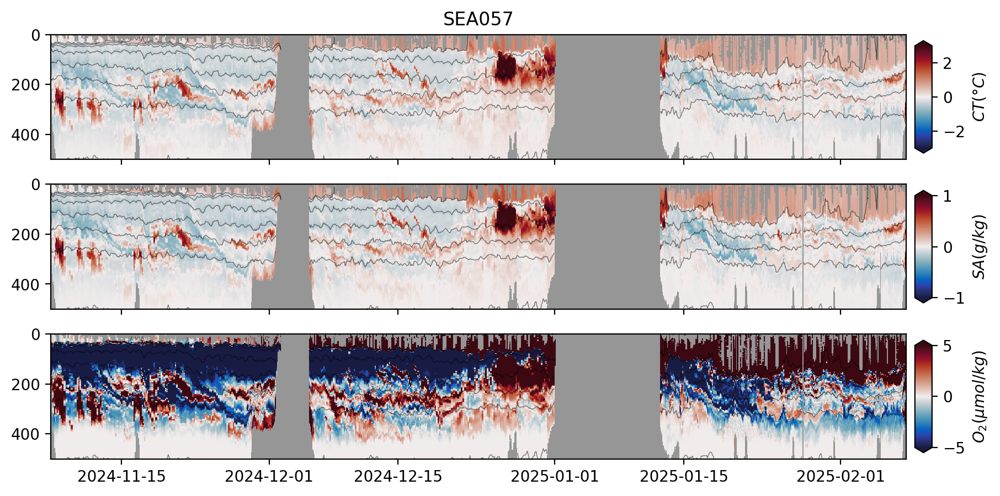

In [48]:
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(10, 5),sharex=True,dpi=200)
ax[0].set_facecolor(np.array([1, 1, 1]) / 1.7)
mesh=ax[0].pcolormesh(d57.time_profile, d57.depth, anom_d57_inp.cons_temperature, shading='auto', cmap='cmo.balance',vmin=-3, vmax=3)
cax = ax[0].inset_axes([1.01, 0.05, 0.02, 0.9])
cbar = fig.colorbar(mesh, cax=cax, label=r'$CT (°C)$', extend='both', pad=0.02)
ax[0].contour(d57.time_profile, d57.depth, d57.potential_density, colors='k', linewidths=0.5,alpha=0.5, levels=np.arange(1000, 1030, 0.5))
#ax[0].contour(d57.time_profile, d57.depth, d57.potential_density, colors='c', linewidths=0.5,alpha=0.5, levels=np.array([1025, 1025.25]))
ax[0].set_ylim(a,0)
ax[0].set_title('SEA057')
ax[1].set_facecolor(np.array([1, 1, 1]) / 1.7)
mesh=ax[1].pcolormesh(d57.time_profile, d57.depth, anom_d57_inp.abs_salinity, shading='auto', cmap='cmo.balance',vmin=-1, vmax=1)
cax = ax[1].inset_axes([1.01, 0.05, 0.02, 0.9])
cbar = fig.colorbar(mesh, cax=cax, label=r'$SA (g/kg)$', extend='both', pad=0.02)
ax[1].contour(d57.time_profile, d57.depth, d57.potential_density, colors='k', linewidths=0.5,alpha=0.5, levels=np.arange(1000, 1030, 0.5))
ax[1].set_ylim(a,0)
ax[2].set_facecolor(np.array([1, 1, 1]) / 1.7)
mesh=ax[2].pcolormesh(d57.time_profile, d57.depth, anom_d57_inp.oxygen_corrected, shading='auto', cmap='cmo.balance',vmin=-5, vmax=5)
cax = ax[2].inset_axes([1.01, 0.05, 0.02, 0.9])
cbar = fig.colorbar(mesh, cax=cax, label=r'$O_2 (µmol/kg)$', extend='both', pad=0.02)
ax[2].contour(d57.time_profile, d57.depth, d57.potential_density, colors='k', linewidths=0.5,alpha=0.5, levels=np.arange(1000, 1030, 0.5))
ax[2].set_ylim(a,0)


# Let's investigate

In [20]:
def kinematic_viscosity_sharqawy(SA, CT, p):
    """
    Compute seawater kinematic viscosity using Sharqawy et al. (2010).
    
    Parameters:
    -----------
    SA : Absolute Salinity [g/kg]
    CT : Conservative Temperature [°C]
    p : Pressure [dbar]
    
    Returns:
    --------
    nu : Kinematic viscosity [m²/s]
    mu : Dynamic viscosity [Pa·s]
    """

    # Convert to in-situ temperature and practical salinity
    T = gsw.t_from_CT(SA, CT, p)
    SP = gsw.SP_from_SA(SA, p, 0, 0)  # Approximate location: 0°N, 0°E
    rho = gsw.rho(SA, CT, p)

    # Pure water dynamic viscosity [Pa·s]
    mu_w = 4.2844e-5 + 0.157 / ((T + 64.993)**2 - 91.296)

    # Empirical coefficients
    A = 1.541 + 1.998e-2 * T - 9.52e-5 * T**2
    B = 7.974 - 7.561e-2 * T + 4.724e-4 * T**2

    # Seawater dynamic viscosity [Pa·s]
    mu = mu_w * (1 + A * SP + B * SP**2)

    # Kinematic viscosity [m²/s]
    nu = mu / rho

    return nu, mu

def viscosity(s, t, rho):
    """
    Compute molecular and kinematic viscosity of seawater.

    Parameters:
    -----------
    s : Salinity [g/kg]
    t : Temperature [°C] (in-situ)
    rho : Density [kg/m^3]

    Returns:
    --------
    nu : Kinematic viscosity [m²/s]
    mu : Dynamic (molecular) viscosity [Pa·s]
    """
    # Coefficients from Millero (1974) / Peters & Siedler
    a0 = 2.5116e-6
    a1 = 1.2199e-6
    b0 = 1.4342e-6
    b1 = 1.8267e-8
    c0 = 1.002e-3
    d0 = 1.1709
    d1 = 1.827e-3
    d2 = 89.93

    # Molecular viscosity at salinity = 0
    mu0 = c0 * 10 ** ((d0 * (20 - t) - d1 * (t - 20) ** 2) / (t + d2))

    # Dynamic viscosity at salinity = s
    rs = rho * s
    mu = mu0 * (1 + (a0 + a1 * t) * np.sqrt(rs) + (b0 + b1 * t) * rs)

    # Kinematic viscosity
    nu = mu / rho

    return nu, mu

In [21]:
nu1,mu= kinematic_viscosity_sharqawy(d57.abs_salinity, d57.cons_temperature, d57.pressure)
nu2,mu=viscosity(d57.abs_salinity, d57.cons_temperature, d57.potential_density)

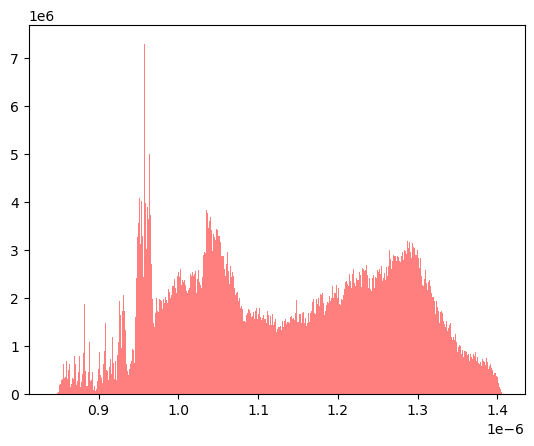

In [22]:
#_=plt.hist(nu1.values.flatten(), bins=100, density=True, color='k', alpha=0.5)
_=plt.hist(nu2.values.flatten(), bins=1000, density=True, color='r', alpha=0.5)

/opt/anaconda3/envs/myenv/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:821: RuntimeWarning: invalid value encountered in log10
  result_data = func(*input_data)


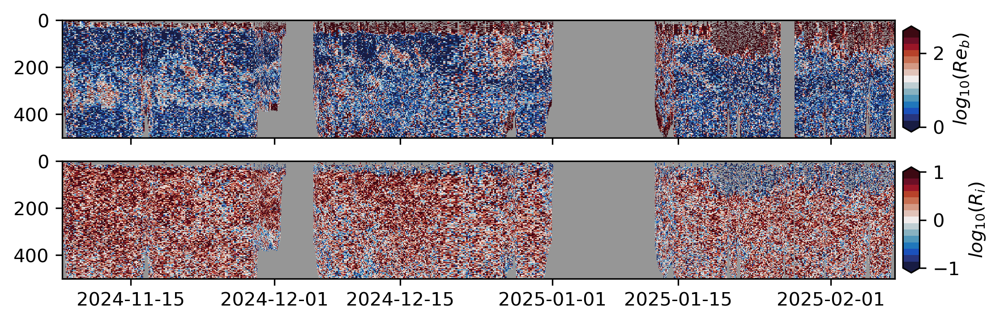

In [27]:
Reb=d57.epsi_QC_gm/(nu2*d57.N2)
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(8, 2.5),sharex=True,dpi=300)
ax[0].set_facecolor(np.array([1, 1, 1]) / 1.7)
mesh=ax[0].pcolormesh(d57.time_profile, d57.depth, np.log10(Reb), shading='auto', cmap=cmo.balance.resampled(15),vmin=0, vmax=2.6)#cmap=plt.colormaps['Spectral_r'].resampled(15)
ax[0].set_ylim(a,0)
cax = ax[0].inset_axes([1.01, 0.05, 0.02, 0.9])
cbar = fig.colorbar(mesh, cax=cax, label=r'$log_{10}(Re_b)$', extend='both', pad=0.02)
ax[1].set_facecolor(np.array([1, 1, 1]) / 1.7)
mesh=ax[1].pcolormesh(d57.time_profile, d57.depth, np.log10(d57.Ri), shading='auto', cmap=cmo.balance.resampled(15),vmin=-1, vmax=1)#cmap=plt.colormaps['Spectral_r'].resampled(15)
ax[1].set_ylim(a,0)
cax = ax[1].inset_axes([1.01, 0.05, 0.02, 0.9])
cbar = fig.colorbar(mesh, cax=cax, label=r'$log_{10}(R_i)$', extend='both', pad=0.02)

Text(0.5, 1.0, '$ \\log_{10}(\\epsilon) $')

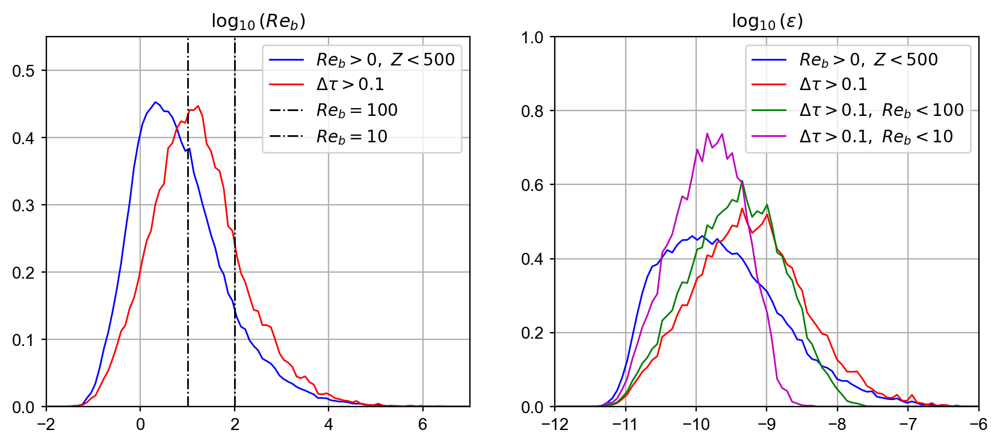

In [89]:
# --- Build robust masks (all broadcast to Reb's shape) ---
base_mask = (Reb >= 0) & (d57.pressure < 500) & (d57.potential_density > 1025)

# Ensure spiciness mask is aligned with Reb's dims
spice_pos = (anom_d57_inp.spiciness > 0.1).broadcast_like(Reb)
spice_neg = (anom_d57_inp.spiciness < -0.1).broadcast_like(Reb)


tau_pos_mask = base_mask & spice_pos & np.isfinite(Reb)
tau_pos_reb_le100_mask = tau_pos_mask & (Reb <= 100)
tau_pos_reb_le10_mask = tau_pos_mask & (Reb <= 10)

# --- Apply masks (no index mixing; xarray aligns by coords) ---
Reb_base = Reb.where(base_mask)
Reb_tau  = Reb.where(tau_pos_mask)

eps = d57.epsi_QC_gm
eps_base = eps.where(base_mask)
eps_tau  = eps.where(tau_pos_mask)
eps_tau_reb100 = eps.where(tau_pos_reb_le100_mask)
eps_tau_reb10 = eps.where(tau_pos_reb_le10_mask)

# --- Helper to make safe log10 vectors for histograms ---
def log10_finite_positive(xr_da):
    arr = xr_da.data.ravel()
    # keep finite & > 0 to avoid -inf/NaN in log10 and histogram bins
    good = np.isfinite(arr) & (arr > 0)
    return np.log10(arr[good])

def plot_pdf(data, bins, color, label):
    vals = log10_finite_positive(data)
    hist, edges = np.histogram(vals, bins=bins, density=True)
    centers = 0.5 * (edges[:-1] + edges[1:])
    plt.plot(centers, hist, color=color, label=label)

plt.figure(figsize=(10, 4), dpi=200)

# --- Left: log10(Re_b) ---
plt.subplot(1, 2, 1)
bins_reb = np.linspace(-2, 7, 100)
plot_pdf(Reb_base, bins_reb, 'b', r'$Re_b > 0,\ Z<500$')
plot_pdf(Reb_tau,  bins_reb, 'r', r'$\Delta \tau > 0.1$')
plt.axvline(np.log10(100), color='k', linestyle='-.', label=r'$Re_b=100$')
plt.axvline(np.log10(10),  color='k', linestyle='-.', label=r'$Re_b=10$')
plt.xlim(-2, 7)
plt.ylim(-0.0, 0.55)

plt.grid(True)
plt.legend()
plt.title(r'$ \log_{10}(Re_b) $')

# --- Right: log10(ε) ---
plt.subplot(1, 2, 2)
bins_eps = np.linspace(-12, -5, 100)
plot_pdf(eps_base,       bins_eps, 'b', r'$Re_b>0,\ Z<500$')
plot_pdf(eps_tau,        bins_eps, 'r', r'$\Delta \tau > 0.1$')
plot_pdf(eps_tau_reb100, bins_eps, 'g', r'$\Delta \tau > 0.1,\ Re_b<100$')
plot_pdf(eps_tau_reb10,  bins_eps, 'm', r'$\Delta \tau > 0.1,\ Re_b<10$')
plt.xlim(-12, -6)
plt.ylim(-0.0, 1)
plt.grid(True)
plt.legend()
plt.title(r'$ \log_{10}(\epsilon) $')
#plt.savefig('Figure_Reb_epsi_distribution.png', dpi=600)

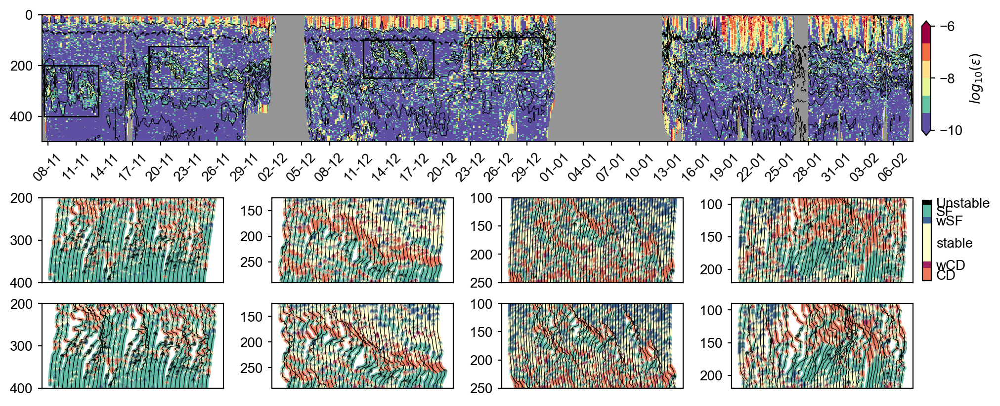

In [90]:
times = np.arange(np.datetime64('2024-11-08'),np.datetime64('2025-02-09'),np.timedelta64(3, 'D'))
labels = pd.to_datetime(times).strftime('%d-%m').tolist()
bounds = [-90, -60, -45, 45, 60, 90, 100.0]
colors=[cmo.matter.resampled(4)(1)[:3],cmo.matter.resampled(4)(2)[:3],cmo.deep.resampled(4)(0)[:3],cmo.deep.resampled(4)(2)[:3],cmo.deep.resampled(4)(1)[:3],cmo.gray.resampled(4)(0)[:3]]
cmap = ListedColormap(colors)
cmap.set_bad(color='none')  # NaNs will be transparent
norm = BoundaryNorm(bounds, len(colors))


fig=plt.figure(figsize=(10,4), constrained_layout=True,dpi=200)
gs = GridSpec(7,8, figure=fig)
ax01 = fig.add_subplot(gs[:3,:])
ax01.set_facecolor(np.array([1, 1, 1]) / 1.7)
mesh=ax01.pcolormesh(d57.time_profile,d57.depth,np.log10(d57.epsi_QC_gm),vmin=-10,vmax=-6,cmap = plt.colormaps['Spectral_r'].resampled(6),zorder=1)#plt.colormaps['Spectral_r'].resampled(6)
cax = ax01.inset_axes([1.01, 0.05, 0.01, 0.9])
cbar = fig.colorbar(mesh, cax=cax, label=r'$log_{10}(\epsilon)$', extend='both', pad=0.02)
ax01.contour(d57.time_profile, d57.depth, anom_d57_inp.spiciness, colors='k', linewidths=0.5,alpha=1, levels=np.arange(-10, 10, 0.5))
#ax01.contour(d57.time_profile, d57.depth, np.abs(d57.spiciness_curvature), colors='k', linewidths=0.5,alpha=0.5, levels=np.arange(-300,300, 100))
ax01.contour(d57.time_profile, d57.depth, d57.potential_density,linestyles='--', colors='k', linewidths=1,alpha=1, levels=np.array([1025]))
ax01.set_ylim(a,0)
ax01.set_xticks(times)
ax01.set_xticklabels(labels,rotation=45);
#
ax01.plot(np.array([d57.time_profile[5].values, d57.time_profile[42].values]), np.array([200, 200]), color='k', linewidth=1)
ax01.plot(np.array([d57.time_profile[5].values, d57.time_profile[42].values]), np.array([400, 400]), color='k', linewidth=1)
ax01.plot(np.array([d57.time_profile[5].values, d57.time_profile[5].values]), np.array([200, 400]), color='k', linewidth=1)
ax01.plot(np.array([d57.time_profile[42].values, d57.time_profile[42].values]), np.array([200, 400]), color='k', linewidth=1)
#
ax01.plot(np.array([d57.time_profile[80].values, d57.time_profile[120].values]), np.array([125, 125]), color='k', linewidth=1)
ax01.plot(np.array([d57.time_profile[80].values, d57.time_profile[120].values]), np.array([290, 290]), color='k', linewidth=1)
ax01.plot(np.array([d57.time_profile[80].values, d57.time_profile[80].values]), np.array([125, 290]), color='k', linewidth=1)
ax01.plot(np.array([d57.time_profile[120].values, d57.time_profile[120].values]), np.array([125,290]), color='k', linewidth=1)
#
ax01.plot(np.array([d57.time_profile[310].values, d57.time_profile[370].values]), np.array([100, 100]), color='k', linewidth=1)
ax01.plot(np.array([d57.time_profile[310].values, d57.time_profile[370].values]), np.array([250, 250]), color='k', linewidth=1)
ax01.plot(np.array([d57.time_profile[310].values, d57.time_profile[310].values]), np.array([100, 250]), color='k', linewidth=1)
ax01.plot(np.array([d57.time_profile[370].values, d57.time_profile[370].values]), np.array([100, 250]), color='k', linewidth=1)
#
ax01.plot(np.array([d57.time_profile[390].values, d57.time_profile[440].values]), np.array([90, 90]), color='k', linewidth=1)
ax01.plot(np.array([d57.time_profile[390].values, d57.time_profile[440].values]), np.array([220, 220]), color='k', linewidth=1)
ax01.plot(np.array([d57.time_profile[390].values, d57.time_profile[390].values]), np.array([90, 220]), color='k', linewidth=1)
ax01.plot(np.array([d57.time_profile[440].values, d57.time_profile[440].values]), np.array([90, 220]), color='k', linewidth=1)

ax02 = fig.add_subplot(gs[3:5,0:2])
idx=(d57.depth.values<400) & (d57.depth.values>200)
profiles = range(5, 42)  # profile indices to plot
offset_step = 2        # horizontal offset between profiles
for n, prof in enumerate(profiles):
    temp = d57.cons_temperature[idx, prof].values
    depth = d57.depth[idx].values
    tu=d57.Tu[idx, prof].values
    ax02.plot(temp + n * offset_step, depth, color='k', linewidth=0.5,zorder=2)
    ax02.scatter(temp + n * offset_step, depth, c=tu,cmap=cmap,norm=norm, s=5,zorder=1,alpha=0.5)
ax02.set_ylim(400, 200)
ax02.set_xticks([])

ax03 = fig.add_subplot(gs[5:7,0:2])
offset_step = 0.35        # horizontal offset between profiles
for n, prof in enumerate(profiles):
    sal = d57.abs_salinity[idx, prof].values
    depth = d57.depth[idx].values
    tu=d57.Tu[idx, prof].values
    ax03.plot(sal + n * offset_step, depth, color='k', linewidth=0.5)
    ax03.scatter(sal + n * offset_step, depth, c=tu,cmap=cmap,norm=norm, s=5,zorder=1,alpha=0.5)
ax03.set_ylim(400, 200)
ax03.set_xticks([])

ax04 = fig.add_subplot(gs[3:5,2:4])
idx=(d57.depth.values<290) & (d57.depth.values>125)
profiles = range(80, 120)  # profile indices to plot
offset_step = 2        # horizontal offset between profiles
for n, prof in enumerate(profiles):
    temp = d57.cons_temperature[idx, prof].values
    depth = d57.depth[idx].values
    tu=d57.Tu[idx, prof].values
    ax04.plot(temp + n * offset_step, depth, color='k', linewidth=0.5)
    ax04.scatter(temp + n * offset_step, depth, c=tu,cmap=cmap,norm=norm, s=5,zorder=1,alpha=0.5)
ax04.set_ylim(290, 125)
ax04.set_xticks([])

ax05 = fig.add_subplot(gs[5:7,2:4])
offset_step = 0.35        # horizontal offset between profiles
for n, prof in enumerate(profiles):
    sal = d57.abs_salinity[idx, prof].values
    depth = d57.depth[idx].values
    tu=d57.Tu[idx, prof].values
    ax05.plot(sal + n * offset_step, depth, color='k', linewidth=0.5)
    ax05.scatter(sal + n * offset_step, depth, c=tu,cmap=cmap,norm=norm, s=5,zorder=1,alpha=0.5)
ax05.set_ylim(290, 125)
ax05.set_xticks([])

ax06 = fig.add_subplot(gs[3:5,4:6])
idx=(d57.depth.values<250) & (d57.depth.values>100)
profiles = range(310, 370)  # profile indices to plot
offset_step = 2        # horizontal offset between profiles
for n, prof in enumerate(profiles):
    temp = d57.cons_temperature[idx, prof].values
    depth = d57.depth[idx].values
    tu=d57.Tu[idx, prof].values
    ax06.plot(temp + n * offset_step, depth, color='k', linewidth=0.5)
    ax06.scatter(temp + n * offset_step, depth, c=tu,cmap=cmap,norm=norm, s=5,zorder=1,alpha=0.5)
ax06.set_ylim(250, 100)
ax06.set_xticks([])

ax07 = fig.add_subplot(gs[5:7,4:6])
offset_step = 0.35        # horizontal offset between profiles
for n, prof in enumerate(profiles):
    sal = d57.abs_salinity[idx, prof].values
    depth = d57.depth[idx].values
    tu=d57.Tu[idx, prof].values
    ax07.plot(sal + n * offset_step, depth, color='k', linewidth=0.5)
    ax07.scatter(sal + n * offset_step, depth, c=tu,cmap=cmap,norm=norm, s=5,zorder=1,alpha=0.5)
ax07.set_ylim(250, 100)
ax07.set_xticks([])

ax08 = fig.add_subplot(gs[3:5,6:8])
idx=(d57.depth.values<220) & (d57.depth.values>90)
profiles = range(390, 440)  # profile indices to plot
offset_step = 2        # horizontal offset between profiles
for n, prof in enumerate(profiles):
    temp = d57.cons_temperature[idx, prof].values
    depth = d57.depth[idx].values
    tu=d57.Tu[idx, prof].values
    ax08.plot(temp + n * offset_step, depth, color='k', linewidth=0.5)
    ax08.scatter(temp + n * offset_step, depth, c=tu,cmap=cmap,norm=norm, s=5,zorder=1,alpha=0.5)
ax08.set_ylim(220, 90)
ax08.set_xticks([])

ax09 = fig.add_subplot(gs[5:7,6:8])
offset_step = 0.35        # horizontal offset between profiles
for n, prof in enumerate(profiles):
    sal = d57.abs_salinity[idx, prof].values
    depth = d57.depth[idx].values
    tu=d57.Tu[idx, prof].values
    ax09.plot(sal + n * offset_step, depth, color='k', linewidth=0.5)
    ax09.scatter(sal + n * offset_step, depth, c=tu,cmap=cmap,norm=norm, s=5,zorder=1,alpha=0.5)
ax09.set_ylim(220, 90)
ax09.set_xticks([])
cmap = ListedColormap(colors)
cmap.set_bad(color='none')  # NaNs will be transparent
norm = BoundaryNorm(bounds, len(colors))
# Add the colorbar to your existing inset axes
cax = ax08.inset_axes([1.05, 0.02, 0.05, 0.95])
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
# Add the colorbar into the given axis cax
ticks = [-75, -52.5, 0, 52.5, 75, 95]
labels = ['CD', 'wCD', 'stable', 'wSF', 'SF', 'Unstable']
cbar = plt.colorbar(sm, cax=cax, boundaries=bounds, spacing='proportional', pad=0.02)
cbar.ax.tick_params(axis='y', which='both', length=0)
cbar.set_ticks(ticks);
cbar.ax.set_yticklabels(labels);
#plt.savefig('Figure_epsilon.png', dpi=600)

In [91]:
def load_fast(uid_, uid_code, varname):
    """
    Load the fast parquet file corresponding to uid_code
    and return P_fast plus the requested variable(s).

    Parameters
    ----------
    uid_ : xarray.Dataset
        The uid_files.nc opened with xr.open_dataset
    uid_code : int
        Numeric identifier of the file
    varname : str or list of str
        Variable(s) to load in addition to P_fast

    Returns
    -------
    ds : xarray.Dataset
        Contains P_fast and requested variable(s)
    """
    if isinstance(varname, str):
        varname = [varname]

    # Find row for this uid_code
    matches = (uid_['uid_code'].values == uid_code).nonzero()[0]
    if len(matches) == 0:
        raise ValueError(f"uid_code {uid_code} not found in uid_files.nc")
    row = int(matches[0])

    source_dir  = str(uid_['source_dir'].values[row])
    source_file = str(uid_['source_file'].values[row])

    # Build fast filename
    fast_file = source_file.replace('.pqt', '_fast.pqt')
    fast_path = os.path.join('/Volumes/WD_BLACK/2024_OMAN', source_dir, fast_file)

    if not os.path.exists(fast_path):
        raise FileNotFoundError(f"Fast file not found: {fast_path}")

    # Always include P_fast
    cols = ['P_fast'] + varname
    df = pd.read_parquet(fast_path, columns=cols)

    # Convert to xarray Dataset
    ds = xr.Dataset.from_dataframe(df)

    # Add uid_code as a coordinate
    ds = ds.assign_coords(uid_code=uid_code)

    return ds

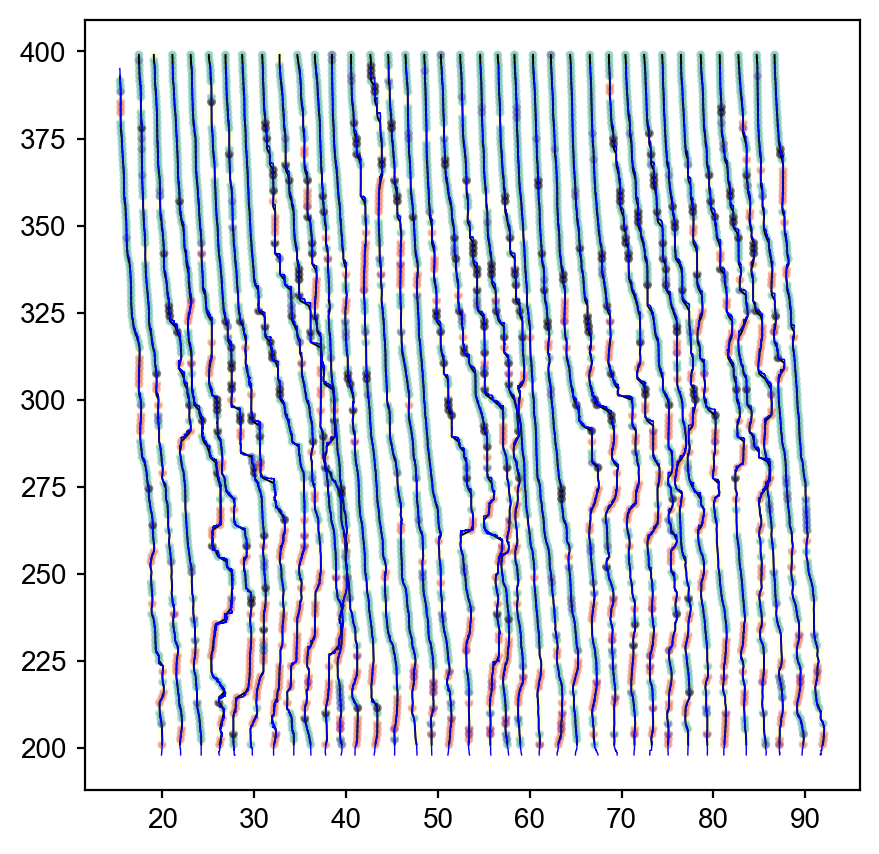

In [100]:
idx=(d57.depth.values<400) & (d57.depth.values>200)
profiles = range(5, 42)  # profile indices to plot
offset_step = 2        # horizontal offset between profiles
plt.figure(figsize=(5,5), dpi=200)
for n, prof in enumerate(profiles):
    spi = d57.temperature[idx, prof].values
    depth = d57.depth[idx].values
    tu=d57.Tu[idx, prof].values
    df_fast = load_fast(uid_, np.nanmin(d57.uid_code[idx,prof].values).astype(int), 'T1_fast')
    df_fast = df_fast.where((df_fast['P_fast'] >= np.min(depth)) & (df_fast['P_fast'] <= np.max(depth)), drop=True)
    plt.plot(spi + n * offset_step, depth, color='k', linewidth=0.7)
    plt.plot(df_fast['T1_fast']+ n * offset_step, df_fast['P_fast']-3,color='b',linewidth=0.5)
    plt.scatter(spi + n * offset_step, depth, c=tu,cmap=cmap,norm=norm, s=5,zorder=1,alpha=0.5)

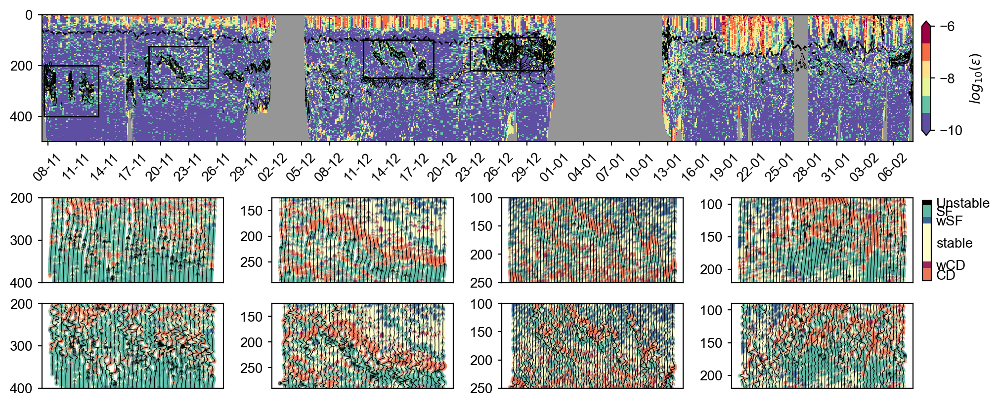

In [94]:
times = np.arange(np.datetime64('2024-11-08'),np.datetime64('2025-02-09'),np.timedelta64(3, 'D'))
labels = pd.to_datetime(times).strftime('%d-%m').tolist()
bounds = [-90, -60, -45, 45, 60, 90, 100.0]
colors=[cmo.matter.resampled(4)(1)[:3],cmo.matter.resampled(4)(2)[:3],cmo.deep.resampled(4)(0)[:3],cmo.deep.resampled(4)(2)[:3],cmo.deep.resampled(4)(1)[:3],cmo.gray.resampled(4)(0)[:3]]
cmap = ListedColormap(colors)
cmap.set_bad(color='none')  # NaNs will be transparent
norm = BoundaryNorm(bounds, len(colors))


fig=plt.figure(figsize=(10,4), constrained_layout=True,dpi=200)
gs = GridSpec(7,8, figure=fig)
ax01 = fig.add_subplot(gs[:3,:])
ax01.set_facecolor(np.array([1, 1, 1]) / 1.7)
mesh=ax01.pcolormesh(d57.time_profile,d57.depth,np.log10(d57.epsi_QC_gm),vmin=-10,vmax=-6,cmap = plt.colormaps['Spectral_r'].resampled(6),zorder=1)#plt.colormaps['Spectral_r'].resampled(6)
cax = ax01.inset_axes([1.01, 0.05, 0.01, 0.9])
cbar = fig.colorbar(mesh, cax=cax, label=r'$log_{10}(\epsilon)$', extend='both', pad=0.02)
masked_spice = anom_d57_inp.spiciness.where((anom_d57_inp.spiciness > 0) & (d57.potential_density> 1025))
ax01.contour(d57.time_profile, d57.depth, masked_spice, colors='k', linewidths=0.5,alpha=1, levels=np.arange(-10, 10, 0.2))
#masked_spiciness = d57.spiciness_curvature.where(np.abs(d57.spiciness_curvature) > 50)
#ax01.contour(d57.time_profile, d57.depth, masked_spiciness, colors='k', linewidths=0.5,alpha=0.5, levels=np.arange(-300,300, 50))
ax01.contour(d57.time_profile, d57.depth, d57.potential_density,linestyles='--', colors='k', linewidths=1,alpha=1, levels=np.array([1025]))
ax01.set_ylim(a,0)
ax01.set_xticks(times)
ax01.set_xticklabels(labels,rotation=45);
#
ax01.plot(np.array([d57.time_profile[5].values, d57.time_profile[42].values]), np.array([200, 200]), color='k', linewidth=1)
ax01.plot(np.array([d57.time_profile[5].values, d57.time_profile[42].values]), np.array([400, 400]), color='k', linewidth=1)
ax01.plot(np.array([d57.time_profile[5].values, d57.time_profile[5].values]), np.array([200, 400]), color='k', linewidth=1)
ax01.plot(np.array([d57.time_profile[42].values, d57.time_profile[42].values]), np.array([200, 400]), color='k', linewidth=1)
#
ax01.plot(np.array([d57.time_profile[80].values, d57.time_profile[120].values]), np.array([125, 125]), color='k', linewidth=1)
ax01.plot(np.array([d57.time_profile[80].values, d57.time_profile[120].values]), np.array([290, 290]), color='k', linewidth=1)
ax01.plot(np.array([d57.time_profile[80].values, d57.time_profile[80].values]), np.array([125, 290]), color='k', linewidth=1)
ax01.plot(np.array([d57.time_profile[120].values, d57.time_profile[120].values]), np.array([125,290]), color='k', linewidth=1)
#
ax01.plot(np.array([d57.time_profile[310].values, d57.time_profile[370].values]), np.array([100, 100]), color='k', linewidth=1)
ax01.plot(np.array([d57.time_profile[310].values, d57.time_profile[370].values]), np.array([250, 250]), color='k', linewidth=1)
ax01.plot(np.array([d57.time_profile[310].values, d57.time_profile[310].values]), np.array([100, 250]), color='k', linewidth=1)
ax01.plot(np.array([d57.time_profile[370].values, d57.time_profile[370].values]), np.array([100, 250]), color='k', linewidth=1)
#
ax01.plot(np.array([d57.time_profile[390].values, d57.time_profile[440].values]), np.array([90, 90]), color='k', linewidth=1)
ax01.plot(np.array([d57.time_profile[390].values, d57.time_profile[440].values]), np.array([220, 220]), color='k', linewidth=1)
ax01.plot(np.array([d57.time_profile[390].values, d57.time_profile[390].values]), np.array([90, 220]), color='k', linewidth=1)
ax01.plot(np.array([d57.time_profile[440].values, d57.time_profile[440].values]), np.array([90, 220]), color='k', linewidth=1)

ax02 = fig.add_subplot(gs[3:5,0:2])
idx=(d57.depth.values<400) & (d57.depth.values>200)
profiles = range(5, 42)  # profile indices to plot
offset_step = 2        # horizontal offset between profiles
for n, prof in enumerate(profiles):
    spi = d57.spiciness[idx, prof].values
    depth = d57.depth[idx].values
    tu=d57.Tu[idx, prof].values
    ax02.plot(spi + n * offset_step, depth, color='k', linewidth=0.5,zorder=2)
    ax02.scatter(spi + n * offset_step, depth, c=tu,cmap=cmap,norm=norm, s=5,zorder=1,alpha=0.5)
ax02.set_ylim(400, 200)
ax02.set_xticks([])

ax03 = fig.add_subplot(gs[5:7,0:2])
offset_step = 4       # horizontal offset between profiles
for n, prof in enumerate(profiles):
    spi = (d57.spiciness_curvature[idx, prof].values-np.nanmean(d57.spiciness_curvature[idx, prof].values))/(np.nanstd(d57.spiciness_curvature[idx, prof].values))
    depth = d57.depth[idx].values
    tu=d57.Tu[idx, prof].values
    ax03.plot(spi + n * offset_step, depth, color='k', linewidth=0.5)
    ax03.scatter(spi + n * offset_step, depth, c=tu,cmap=cmap,norm=norm, s=5,zorder=1,alpha=0.5)
ax03.set_ylim(400, 200)
ax03.set_xticks([])

ax04 = fig.add_subplot(gs[3:5,2:4])
idx=(d57.depth.values<290) & (d57.depth.values>125)
profiles = range(80, 120)  # profile indices to plot
offset_step = 2        # horizontal offset between profiles
for n, prof in enumerate(profiles):
    spi = d57.spiciness[idx, prof].values
    depth = d57.depth[idx].values
    tu=d57.Tu[idx, prof].values
    ax04.plot(spi + n * offset_step, depth, color='k', linewidth=0.5)
    ax04.scatter(spi + n * offset_step, depth, c=tu,cmap=cmap,norm=norm, s=5,zorder=1,alpha=0.5)
ax04.set_ylim(290, 125)
ax04.set_xticks([])

ax05 = fig.add_subplot(gs[5:7,2:4])
offset_step = 4        # horizontal offset between profiles
for n, prof in enumerate(profiles):
    spi = (d57.spiciness_curvature[idx, prof].values-np.nanmean(d57.spiciness_curvature[idx, prof].values))/(np.nanstd(d57.spiciness_curvature[idx, prof].values))
    depth = d57.depth[idx].values
    tu=d57.Tu[idx, prof].values
    ax05.plot(spi + n * offset_step, depth, color='k', linewidth=0.5)
    ax05.scatter(spi + n * offset_step, depth, c=tu,cmap=cmap,norm=norm, s=5,zorder=1,alpha=0.5)
ax05.set_ylim(290, 125)
ax05.set_xticks([])

ax06 = fig.add_subplot(gs[3:5,4:6])
idx=(d57.depth.values<250) & (d57.depth.values>100)
profiles = range(310, 370)  # profile indices to plot
offset_step = 2        # horizontal offset between profiles
for n, prof in enumerate(profiles):
    spi = d57.spiciness[idx, prof].values
    depth = d57.depth[idx].values
    tu=d57.Tu[idx, prof].values
    ax06.plot(spi + n * offset_step, depth, color='k', linewidth=0.5)
    ax06.scatter(spi + n * offset_step, depth, c=tu,cmap=cmap,norm=norm, s=5,zorder=1,alpha=0.5)
ax06.set_ylim(250, 100)
ax06.set_xticks([])

ax07 = fig.add_subplot(gs[5:7,4:6])
offset_step = 4        # horizontal offset between profiles
for n, prof in enumerate(profiles):
    spi = (d57.spiciness_curvature[idx, prof].values-np.nanmean(d57.spiciness_curvature[idx, prof].values))/(np.nanstd(d57.spiciness_curvature[idx, prof].values))
    depth = d57.depth[idx].values
    tu=d57.Tu[idx, prof].values
    ax07.plot(spi + n * offset_step, depth, color='k', linewidth=0.5)
    ax07.scatter(spi + n * offset_step, depth, c=tu,cmap=cmap,norm=norm, s=5,zorder=1,alpha=0.5)
ax07.set_ylim(250, 100)
ax07.set_xticks([])

ax08 = fig.add_subplot(gs[3:5,6:8])
idx=(d57.depth.values<220) & (d57.depth.values>90)
profiles = range(390, 440)  # profile indices to plot
offset_step = 2        # horizontal offset between profiles
for n, prof in enumerate(profiles):
    spi = d57.spiciness[idx, prof].values
    depth = d57.depth[idx].values
    tu=d57.Tu[idx, prof].values
    ax08.plot(spi + n * offset_step, depth, color='k', linewidth=0.5)
    ax08.scatter(spi + n * offset_step, depth, c=tu,cmap=cmap,norm=norm, s=5,zorder=1,alpha=0.5)
ax08.set_ylim(220, 90)
ax08.set_xticks([])

ax09 = fig.add_subplot(gs[5:7,6:8])
offset_step = 4        # horizontal offset between profiles
for n, prof in enumerate(profiles):
    spi = (d57.spiciness_curvature[idx, prof].values-np.nanmean(d57.spiciness_curvature[idx, prof].values))/(np.nanstd(d57.spiciness_curvature[idx, prof].values))
    depth = d57.depth[idx].values
    tu=d57.Tu[idx, prof].values
    ax09.plot(spi + n * offset_step, depth, color='k', linewidth=0.5)
    ax09.scatter(spi + n * offset_step, depth, c=tu,cmap=cmap,norm=norm, s=5,zorder=1,alpha=0.5)
ax09.set_ylim(220, 90)
ax09.set_xticks([])
cmap = ListedColormap(colors)
cmap.set_bad(color='none')  # NaNs will be transparent
norm = BoundaryNorm(bounds, len(colors))
# Add the colorbar to your existing inset axes
cax = ax08.inset_axes([1.05, 0.02, 0.05, 0.95])
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
# Add the colorbar into the given axis cax
ticks = [-75, -52.5, 0, 52.5, 75, 95]
labels = ['CD', 'wCD', 'stable', 'wSF', 'SF', 'Unstable']
cbar = plt.colorbar(sm, cax=cax, boundaries=bounds, spacing='proportional', pad=0.02)
cbar.ax.tick_params(axis='y', which='both', length=0)
cbar.set_ticks(ticks);
cbar.ax.set_yticklabels(labels);
#plt.savefig('Figure_epsilon_waterfall_spice.png', dpi=600)